STEP 1 — IMPORT LIBRARIES

In [1]:
# ======================================
# IMPORT LIBRARIES
# ======================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

print("Libraries imported successfully.")

Libraries imported successfully.


STEP 2 — LOAD FINAL INTELLIGENCE DATASET

In [3]:
# ======================================
# LOAD FINAL DATASET
# ======================================

df = pd.read_csv(
    "../data/final_enterprise_energy_intelligence.csv"
)

print("Dataset loaded successfully.")

display(df.head())

Dataset loaded successfully.


,circle,division,subdivision,section,area,catdesc,catcode,totservices,billdservices,units,load,units_per_service,service_utilization_ratio,avg_load_per_service,load_efficiency,efficiency_category,anomaly_score,anomaly,risk_category
0,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,MAHATMA NAGAR,NON-DOMESTIC AND COMMERCIAL,2,24,22.0,3334,30.44,138.916667,0.916667,1.268333,109.526938,HIGH EFFICIENCY,0.248554,1,LOW RISK
1,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM -I (S),NON-DOMESTIC AND COMMERCIAL,2,77,76.0,9443,117.27,122.636364,0.987013,1.522987,80.523578,MEDIUM EFFICIENCY,0.249390,1,LOW RISK
2,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - II,NON-DOMESTIC AND COMMERCIAL,2,24,23.0,3242,29.74,135.083333,0.958333,1.239167,109.011432,HIGH EFFICIENCY,0.245748,1,LOW RISK
3,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE - III,NON-DOMESTIC AND COMMERCIAL,2,105,101.0,16863,144.92,160.600000,0.961905,1.380190,116.360751,HIGH EFFICIENCY,0.216413,1,LOW RISK
4,BANJARA HILLS,GREEN LANDS,SANATH NAGAR,MOTHI NAGAR,N.R.R.PURAM SITE -I,NON-DOMESTIC AND COMMERCIAL,2,101,99.0,6767,101.00,67.000000,0.980198,1.000000,67.000000,MEDIUM EFFICIENCY,0.236657,1,LOW RISK


STEP 3 — CREATE OPTIMIZATION CONDITIONS

In [4]:
# ======================================
# OPTIMIZATION CONDITIONS
# ======================================

conditions = [

    # HIGH RISK + HIGH LOAD
    (
        (df['risk_category'] == 'HIGH RISK') &
        (df['load'] > df['load'].mean())
    ),

    # LOW EFFICIENCY
    (
        df['load_efficiency'] < 50
    ),

    # HIGH SERVICE UTILIZATION
    (
        df['service_utilization_ratio'] > 0.90
    ),

    # NORMAL OPERATIONS
    (
        df['risk_category'] == 'LOW RISK'
    )

]

recommendations = [

    "Immediate energy audit required. Optimize operational load balancing.",

    "Improve energy efficiency and inspect equipment performance.",

    "Reduce peak operational dependency and redistribute services.",

    "Operations are stable. Maintain current optimization strategy."

]

print("Optimization rules created successfully.")

Optimization rules created successfully.


STEP 4 — GENERATE AI RECOMMENDATIONS

In [5]:
# ======================================
# GENERATE RECOMMENDATIONS
# ======================================

df['optimization_recommendation'] = np.select(
    conditions,
    recommendations,
    default="Monitor operational patterns for future optimization."
)

print("AI recommendations generated successfully.")

display(
    df[
        [
            'area',
            'risk_category',
            'load_efficiency',
            'optimization_recommendation'
        ]
    ].head()
)

AI recommendations generated successfully.


,area,risk_category,load_efficiency,optimization_recommendation
0,MAHATMA NAGAR,LOW RISK,109.526938,Reduce peak operational dependency and redistr...
1,N.R.R.PURAM -I (S),LOW RISK,80.523578,Reduce peak operational dependency and redistr...
2,N.R.R.PURAM SITE - II,LOW RISK,109.011432,Reduce peak operational dependency and redistr...
3,N.R.R.PURAM SITE - III,LOW RISK,116.360751,Reduce peak operational dependency and redistr...
4,N.R.R.PURAM SITE -I,LOW RISK,67.000000,Reduce peak operational dependency and redistr...


STEP 5 — PRIORITY CLASSIFICATION

In [6]:
# ======================================
# PRIORITY CLASSIFICATION
# ======================================

priority_conditions = [

    df['risk_category'] == 'HIGH RISK',

    df['risk_category'] == 'MEDIUM RISK',

    df['risk_category'] == 'LOW RISK'

]

priority_labels = [

    'HIGH PRIORITY',

    'MEDIUM PRIORITY',

    'LOW PRIORITY'

]

df['priority_level'] = np.select(
    priority_conditions,
    priority_labels,
    default='UNKNOWN'
)

print("Priority levels assigned successfully.")

Priority levels assigned successfully.


STEP 6 — PRIORITY DISTRIBUTION

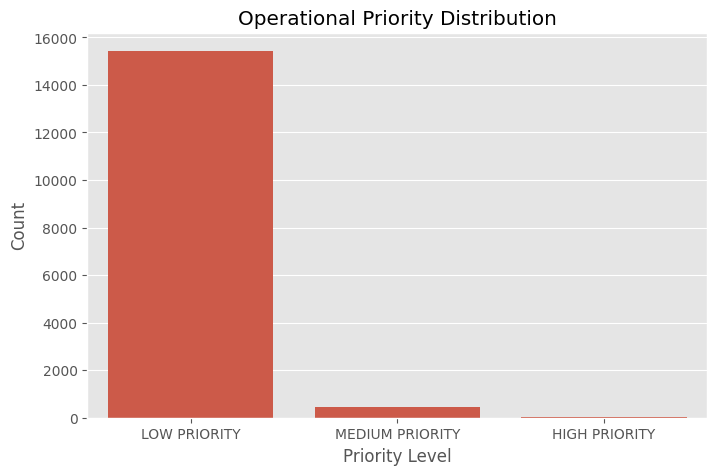

In [7]:
# ======================================
# PRIORITY DISTRIBUTION
# ======================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='priority_level'
)

plt.title("Operational Priority Distribution")

plt.xlabel("Priority Level")

plt.ylabel("Count")

plt.show()

STEP 7 — TOP HIGH PRIORITY AREAS

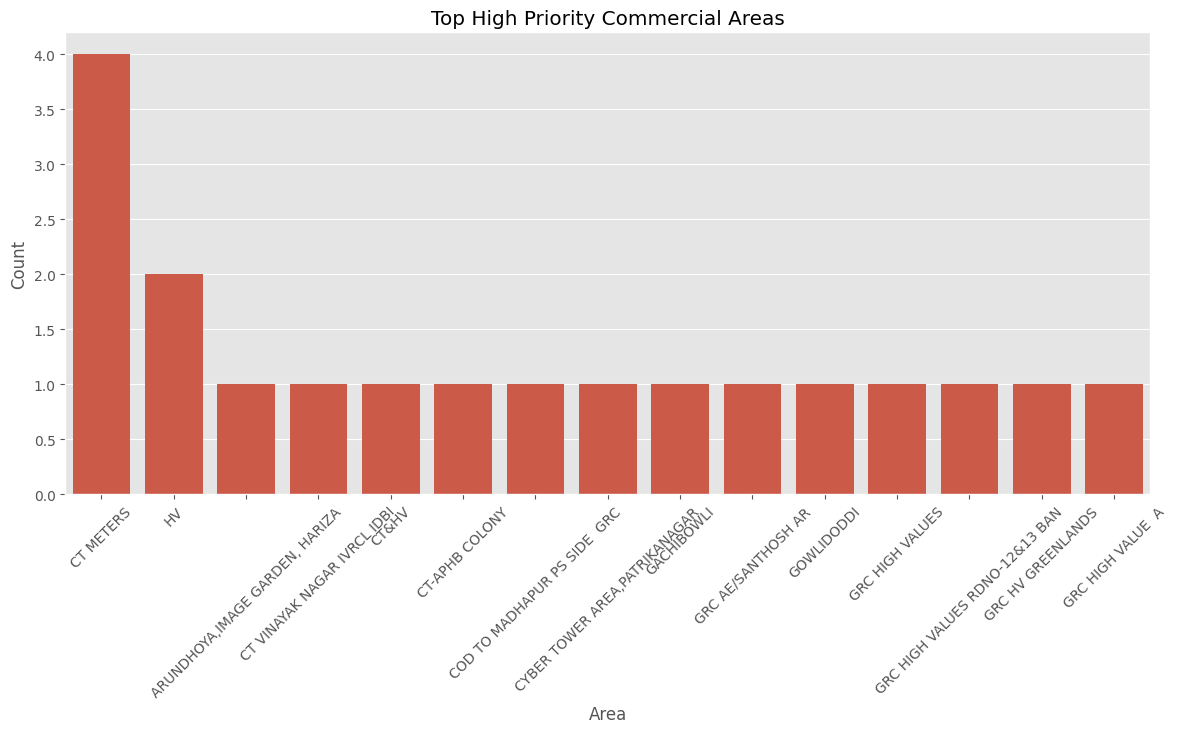

In [8]:
# ======================================
# HIGH PRIORITY REGIONS
# ======================================

high_priority_areas = (
    df[df['priority_level'] == 'HIGH PRIORITY']
    .groupby('area')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=high_priority_areas.index,
    y=high_priority_areas.values
)

plt.title("Top High Priority Commercial Areas")

plt.xlabel("Area")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

STEP 8 — ESTIMATED SAVINGS OPPORTUNITY

In [9]:
# ======================================
# ESTIMATED SAVINGS
# ======================================

df['estimated_savings_units'] = np.where(
    df['priority_level'] == 'HIGH PRIORITY',
    df['units'] * 0.15,
    df['units'] * 0.05
)

print("Estimated savings calculated successfully.")

display(
    df[
        [
            'area',
            'units',
            'estimated_savings_units'
        ]
    ].head()
)

Estimated savings calculated successfully.


,area,units,estimated_savings_units
0,MAHATMA NAGAR,3334,166.70
1,N.R.R.PURAM -I (S),9443,472.15
2,N.R.R.PURAM SITE - II,3242,162.10
3,N.R.R.PURAM SITE - III,16863,843.15
4,N.R.R.PURAM SITE -I,6767,338.35


STEP 9 — EXECUTIVE INSIGHTS

In [10]:
# ======================================
# EXECUTIVE INSIGHTS
# ======================================

total_savings = df['estimated_savings_units'].sum()

high_risk_count = (
    df['priority_level'] == 'HIGH PRIORITY'
).sum()

print("===== EXECUTIVE INSIGHTS =====")

print(f"Estimated Total Savings Units: {total_savings:,.2f}")

print(f"High Priority Operational Regions: {high_risk_count}")

===== EXECUTIVE INSIGHTS =====
Estimated Total Savings Units: 23,035,477.75
High Priority Operational Regions: 43


STEP 10 — EXPORT FINAL RECOMMENDATION DATASET

In [12]:
# ======================================
# EXPORT FINAL DATASET
# ======================================

df.to_csv(
    "../data/optimization_recommendations.csv",
    index=False
)

print("Optimization recommendation dataset exported successfully.")

Optimization recommendation dataset exported successfully.
